## Now import ModelFlow

In [ ]:
# Install ModelFlow into this browser session (needed in every notebook, after every reload).
# numba, cvxopt and dash are not available in the browser; ModelFlow runs without them.
%pip install -q numpy pandas scipy matplotlib sympy networkx tqdm seaborn openpyxl ipywidgets ipydatagrid
# ModelFlow itself, without its desktop-only dependencies
%pip install -q --no-deps modelflowib

# numba does not exist in the browser. ModelFlow 2.78's generated solver code imports it even
# when nothing is compiled, so give it a stand-in that leaves functions uncompiled.
import sys, types
_nojit = lambda *a, **k: a[0] if len(a) == 1 and callable(a[0]) and not k else (lambda f: f)
sys.modules['numba'] = types.SimpleNamespace(jit=_nojit, njit=_nojit)

In [1]:
from modelclass import model

## Load the Pakistan model and run the baseline

In [2]:
mpak,bline = model.modelload('data/pak_new.pcim',run=True,keep='Baseline')

Zipped file read:  data\pak_new.pcim


In [4]:
var_descriptions = {
    'PAKCCEMISCO2CKN': 'Coal emissions, tCO2e',
    'PAKCCEMISCO2GKN': 'Natural Gas emissions, tCO2e',
    'PAKCCEMISCO2OKN': 'Crude Oil emissions, tCO2e',
    'PAKCCEMISCO2TKN': 'Total emissions, tCO2e',
}

mpak.var_description = mpak.var_description | var_descriptions

In [6]:
mpak.modeldump('data/pak.pcim')

In [5]:
mpak.PAKCCEMISCO2CKN

Endogeneous: PAKCCEMISCO2CKN: Coal emissions, tCO2e
Formular: FRML <IDENT> PAKCCEMISCO2CKN = (1000*EMISCOAL)*(PAKNVCOLPRODQN+PAKNVCOLNIMPQN) $

PAKCCEMISCO2CKN: Coal emissions, tCO2e
EMISCOAL       : 
PAKNVCOLNIMPQN : Coal, net import (ktoe)
PAKNVCOLPRODQN : Coal, production (ktoe)

Values :


,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
Base,"25,012,089.24","42,705,000.56","44,509,676.94","47,524,592.82","49,325,933.94","50,582,181.34","51,614,522.31","52,720,732.11","53,984,831.65","55,377,238.16","56,828,957.24","58,282,714.23","59,710,259.74","61,108,811.22","62,489,129.92"
Last,"25,012,089.24","42,705,000.56","44,509,676.94","47,524,592.82","49,325,933.94","50,582,181.34","51,614,522.31","52,720,732.11","53,984,831.65","55,377,238.16","56,828,957.24","58,282,714.23","59,710,259.74","61,108,811.22","62,489,129.92"
Diff,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Input last run:


,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
EMISCOAL,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96,3.96
PAKNVCOLNIMPQN,"4,624.17","9,062.63","9,531.70","10,262.67","10,710.28","11,021.36","11,267.81","11,518.35","11,793.88","12,089.70","12,391.70","12,687.95","12,972.76","13,246.09","13,510.99"
PAKNVCOLPRODQN,"1,690.88","1,719.52","1,706.10","1,736.33","1,743.52","1,749.62","1,763.81","1,792.57","1,836.20","1,891.93","1,956.46","2,027.26","2,102.88","2,182.65","2,266.26"


## Simulating the impact of imposing a carbon price

A simulation follows three steps:

1. **Create a scenario DataFrame** from a baseline using `.upd()`, which applies an update expression that sets, scales, or grows selected variables over a chosen time range.
2. **Solve the model** by calling it with the scenario DataFrame, a start and end year, and a `keep=` label that names the scenario for later comparison.
3. **Inspect results** on the returned DataFrame or directly on the model, which stores each kept scenario.

In [8]:
CT30df = bline.upd("<2025 2050> PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER = 30")

**Breakdown** 


$$
\begin{aligned}
&\underbrace{\texttt{CT30df}}_{\text{scenario df}}
 = \underbrace{\texttt{bline}}_{\text{baseline}}
 \,.\,\underbrace{\texttt{upd}}_{\text{accessor}}\bigl(\texttt{"}\ldots\texttt{"}\bigr) \\[8pt]
&\text{where the update string is} \\[4pt]
&\texttt{"}\,
 \overbrace{\texttt{<2025 2050>}}^{\text{years}}\ 
 \overbrace{\texttt{PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER}}^{\text{coal, gas, oil CO}_2\text{ tax rates}}\ 
 \overbrace{\texttt{=}}^{\text{set}}\ 
 \overbrace{\texttt{30}}^{\text{USD/tCO}_2}
 \,\texttt{"}
\end{aligned}
$$

### Solve the model

In [9]:
resultsdf = mpak(CT30df,2020,2050,keep="Nominal $30USD Carbon tax")

**Breakdown**
$$
\small
\underbrace{\texttt{resultsdf}}_{\text{results df}}
= \underbrace{\texttt{mpak}}_{\text{model}}\bigl(
\underbrace{\texttt{CT30df}}_{\text{scenario df}},\;
\underbrace{\texttt{2020}}_{\text{start}},\;
\underbrace{\texttt{2050}}_{\text{end}},\;
\underbrace{\texttt{keep="Nominal \$30USD Carbon tax"}}_{\text{scenario label}}
\bigr)
$$

### Readable labels for the emission variables

To make tables and plots easier to read, we attach short descriptions to each emission variable and merge them into `mpak.var_description`. These labels can then be used instead of the raw codes wherever the model displays results.

### Inspect results

 **Note**
 
 `resultsdf` is rarely used directly. The model object `mpak` keeps the baseline (`mpak.basedf`) and the latest run (`mpak.lastdf`) internally, so the following cells can compare and plot results directly from `mpak`.

In [11]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN']

### Demo cue-sheet — causality dashboard (carbon tax → emissions → GDP)

Recording sequence for the Venice talk (each step triggers a ~1 s graph morph):

1. Start on GDP `PAKNYGDPMKTPCN`, **Up = 1**, Down = 0 → small graph.
2. Increase **Up: 1 → 2 → 3 → 4** (pause ~2 s each) — GDP's upstream drivers unfold.
3. Dropdown → `PAKCCEMISCO2TKN` (total emissions) — graph morphs to the emissions block.
4. Show the **Chart** and **Attribution** tabs — the $30-tax impact numbers.
5. Toggle **Node display: Name → +values → +Attribution**; flip **orientation V → H**.

_Record the browser tab (OBS / `Win+Alt+R`) → export MP4 (H.264/AAC) → embed in PowerPoint._

In [15]:
mpak.PAKNYGDPMKTPCN

Endogeneous: PAKNYGDPMKTPCN: GDP, Market Prices, LCU mn
Formular: FRML <IDENT> PAKNYGDPMKTPCN = PAKNECONPRVTCN+PAKNECONGOVTCN+PAKNEGDIFTOTCN+PAKNEGDISTKBCN+PAKNEEXPGNFSCN-PAKNEIMPGNFSCN+PAKNYGDPDISCCN+PAKADAP*PAKDISPREPCN $

PAKNYGDPMKTPCN: GDP, Market Prices, LCU mn
PAKADAP       : 
PAKDISPREPCN  : 
PAKNECONGOVTCN: Govt. Cons., LCU mn
PAKNECONPRVTCN: Pvt. Cons., LCU mn
PAKNEEXPGNFSCN: Exp., GNFS (NIA), millions LCU
PAKNEGDIFTOTCN: Fixed Domestic Inv., LCU mn
PAKNEGDISTKBCN: Change in stock, LCU mn
PAKNEIMPGNFSCN: Imp., GNFS (NIA), LCU mn
PAKNYGDPDISCCN: GDP Disc., LCU mn

Values :


,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
Base,"46,180,354.36","51,579,657.82","56,985,483.85","62,594,067.43","68,528,624.18","74,841,107.64","81,534,690.31","88,606,942.99","96,077,333.52","103,995,385.70","112,434,273.18","121,479,584.07","131,220,349.58","141,745,097.05","153,142,299.77","165,503,150.02","178,924,737.94","193,512,462.91","209,381,544.91","226,657,745.58","245,477,825.40","265,990,074.87","288,355,119.80","312,747,059.02","339,354,898.82","368,384,181.75","400,058,773.44","434,622,752.61","472,342,412.83","513,508,380.90","558,437,878.73"
Last,"46,180,354.37","51,579,657.83","56,985,483.87","62,594,067.46","68,528,624.21","76,456,562.97","83,849,697.55","91,343,759.36","99,049,768.05","107,102,705.69","115,610,351.06","124,693,188.03","134,461,552.89","145,015,554.80","156,450,187.30","168,861,627.21","182,351,452.23","197,028,932.69","213,012,087.90","230,428,163.91","249,414,160.29","270,117,687.72","292,698,201.28","317,328,541.54","344,196,616.48","373,507,167.91","405,483,576.95","440,369,725.50","478,431,960.38","519,961,192.45","565,275,170.98"
Diff,0.01,0.02,0.02,0.02,0.03,"1,615,455.33","2,315,007.23","2,736,816.37","2,972,434.53","3,107,320.00","3,176,077.88","3,213,603.96","3,241,203.31","3,270,457.76","3,307,887.53","3,358,477.18","3,426,714.29","3,516,469.78","3,630,542.99","3,770,418.33","3,936,334.88","4,127,612.85","4,343,081.48","4,581,482.52","4,841,717.66","5,122,986.16","5,424,803.52","5,746,972.89","6,089,547.55","6,452,811.55","6,837,292.25"


Input last run:


,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
PAKADAP,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PAKDISPREPCN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PAKNECONGOVTCN,"5,556,614.46","6,367,939.34","7,216,641.70","8,120,204.64","9,082,310.69","10,821,102.94","12,203,133.88","13,494,241.30","14,787,018.19","16,122,188.50","17,510,775.32","18,971,313.49","20,519,431.51","22,168,291.73","23,929,719.00","25,815,611.09","27,838,763.25","30,013,391.48","32,355,433.56","34,882,679.82","37,614,832.92","40,573,555.88","43,782,540.43","47,267,611.88","51,056,859.74","55,180,796.12","59,672,536.90","64,568,007.99","69,906,180.49","75,729,337.56","82,083,376.28"
PAKNECONPRVTCN,"39,450,086.71","43,735,888.94","47,954,011.19","52,344,927.01","57,045,147.66","63,076,447.11","68,578,722.74","74,358,086.29","80,378,602.20","86,715,178.20","93,450,257.03","100,668,699.99","108,447,209.05","116,855,310.41","125,960,538.59","135,833,808.19","146,552,702.19","158,202,773.84","170,877,727.77","184,679,236.46","199,716,979.95","216,109,122.69","233,983,204.73","253,477,330.59","274,741,479.79","297,938,882.14","323,247,422.90","350,861,100.81","380,991,585.11","413,869,898.09","449,748,254.58"
PAKNEEXPGNFSCN,"3,628,934.80","4,153,778.82","4,740,216.42","5,380,480.49","6,071,922.73","6,810,256.01","7,619,191.53","8,477,732.82","9,390,249.81","10,360,796.56","11,394,842.88","12,499,037.08","13,680,994.29","14,949,070.90","16,312,247.70","17,780,114.10","19,362,911.19","21,071,593.89","22,917,895.17","24,914,390.98","27,074,570.86","29,412,920.11","31,945,017.07","34,687,645.94","37,658,923.33","40,878,436.18","44,367,389.07","48,148,760.22","52,247,466.53","56,690,538.75","61,507,308.28"
PAKNEGDIFTOTCN,"5,357,846.53","5,945,053.34","6,516,455.63","7,079,977.54","7,649,429.93","8,756,122.37","9,535,965.96","10,288,944.75","11,064,479.90","11,887,869.88","12,773,927.15","13,742,037.81","14,811,220.33","15,999,382.16","17,323,327.75","18,799,296.99","20,443,504.47","22,272,644.70","24,304,319.36","26,557,375.88","29,052,197.45","31,810,976.37","34,857,992.36","38,219,907.26","41,926,068.98","46,008,825.20","50,503,843.17","55,450,438.17","60,891,916.77","66,875,940.29","73,454,915.38"
PAKNEGDISTKBCN,"655,457.50","711,986.84","773,391.50","840,091.95","912,544.92","991,246.53","1,076,735.69","1,169,597.79","1,270,468.69","1,380,039.12","1,499,059.34","1,628,344.36","1,768,779.44","1,921,326.22","2,087,029.27","2,267,023.22","2,462,540.58","2,674,920.17","2,905,616.24","3,156,208.48","3,428,412.82","3,724,093.19","4,045,274.23","4,394,155.25","4,773,125.19","5,184,779.06","5,631,935.64","6,117,656.83","6,645,268.61","7,218,383.78","7,840,926.76"
PAKNEIMPGNFSCN,"8,468,585.88","9,334,989.73","10,215,232.88","11,171,614.50","12,232,732.08","13,998,612.32","15,164,052.61","16,444,843.96","17,841,051.12","19,363,367.00","21,018,511.11","22,816,245.18","24,766,082.29","26,877,827.22","29,162,675.66","31,634,227.13","34,308,970.27","37,206,392.28","40,348,905.20","43,761,728.79","47,472,834.91","51,512,981.83","55,915,828.97","60,718,110.96","65,959,842.28","71,684,552.66","77,939,552.79","84,776,240.77","92,250,459.57","100,422,908.68","109,359,613.19"
PAKNYGDPDISCCN,0.26,0.28,0.30,0.33,0.36,0.39,0.42,0.46,0.50,0.54,0.59,0.64,0.69,0.75,0.82,0.89,0.96,1.05,1.14,1.23,1.34,1.46,1.58,1.72,1.87,2.03,2.20,2.39,2.60,2.82,3.07


In [19]:
mpak.modeldash('PAKNYGDPMKTPCN')

Dash app running on http://127.0.0.1:5001/


In [16]:
mpak.modeldash('PAKCCEMISCO2TKN')

Dash app running on http://127.0.0.1:5001/


In [13]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN'].rplot(samefig=1,datatype='difpctlevel')

Accordion(children=(HTML(value='<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "…

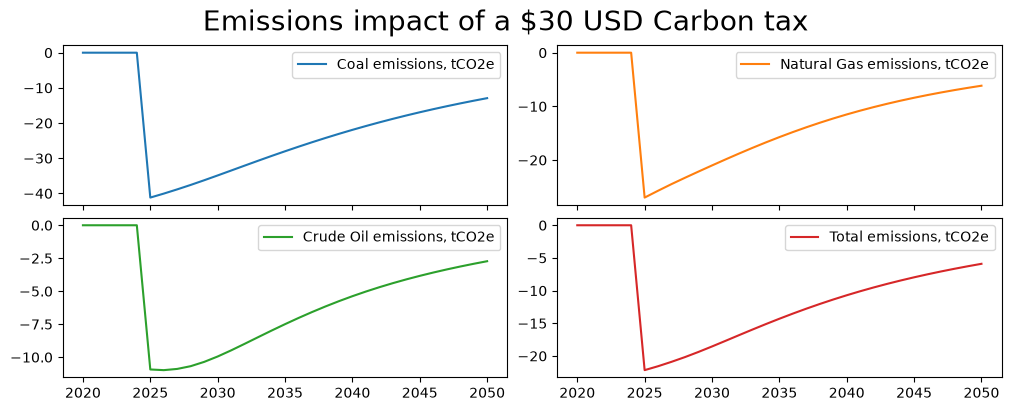

In [14]:
mpak['PAKCCEMISCO2?KN'].difpctlevel.rename().plot(title="Emissions impact of a $30 USD Carbon tax");

**Breakdown**

| Element | What it does |
|:---|---|
| `mpak` | The model object holding the baseline and the latest simulation |
| `['PAKCCEMISCO2*']` | Select all variables matching the pattern — here, CO₂ emissions |
| `.difpctlevel` | Percent difference between the latest simulation and the baseline |
| `.rename()` | Use the variable descriptions |
| `.df` | Return the underlying pandas DataFrame (rows = years, columns = variables) |
| `.T` | Transpose so variables become rows and years become columns |
| `.style.format("{:.2f}")` | Render as a styled table with values shown to two decimal places |